# custom_cnn — Zi Yang

A hand-designed residual depthwise-separable CNN with squeeze-and-excitation and
stochastic depth, trained from scratch under the locked protocol.

This notebook is a copy of `notebooks/_TEMPLATE.ipynb` with only the two
**YOUR MODEL** cells replaced. Everything else is the shared protocol and is
left untouched — that is what makes this macro F1 comparable to everyone else's.

The rules that still matter:

- The test split is touched exactly once, by `save_run`, after the best epoch is
  already fixed by **validation** macro F1. Never tune against test.
- Set `pretrained=` honestly in `save_run`. It is the one field that corrupts the
  results table if it is wrong.
- Don't edit `protocol.yaml` for your own run. If the team changes it, every model
  is re-run.

## 1. Setup

Works locally and on Colab. On Colab this clones the repo and expects the IP102
images on your Drive; adjust `DRIVE_IMAGES` to wherever you put them.

In [2]:
import sys, subprocess
from pathlib import Path

IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    REPO = 'https://github.com/<org>/FarmPestManagementAI.git'
    DRIVE_IMAGES = '/content/drive/MyDrive/IP102/JPEGImages'  # <- where your images live

    from google.colab import drive; drive.mount('/content/drive')
    if not Path('FarmPestManagementAI').exists():
        subprocess.run(['git', 'clone', REPO], check=True)
    %cd FarmPestManagementAI
    subprocess.run([sys.executable, '-m', 'pip', 'install', '-q', '-r', 'requirements.txt'], check=True)

    # Point the protocol at the Drive copy instead of a local extraction.
    import yaml
    p = yaml.safe_load(open('protocol.yaml'))
    p['dataset']['subsets'][p['dataset']['subset']]['images'] = DRIVE_IMAGES
    yaml.safe_dump(p, open('protocol.yaml', 'w'), sort_keys=False)
else:
    # Running from notebooks/ — put the repo root on the path.
    sys.path.insert(0, str(Path.cwd().parent))

In [3]:
import torch
import torch.nn as nn

from ip102_bench import (
    load_protocol, build_dataloaders, train_model, save_run,
    count_parameters, resolve_device, seed_everything,
)

protocol = load_protocol()
device   = resolve_device(protocol.runtime.get('device', 'auto'))
seed_everything(protocol.seed)

print(f"subset      : {protocol.subset_name} ({protocol.num_classes} classes)")
print(f"crop        : {protocol.crop_mode}, margin {protocol.crop_margin}")
print(f"image size  : {protocol.image_size}")
print(f"batch/epochs: {protocol.batch_size} / {protocol.epochs}")
print(f"seed        : {protocol.seed}")
print(f"device      : {device}")
print(f"classes     : {protocol.class_names}")

subset      : detection_top15 (15 classes)
crop        : box, margin 0.25
image size  : 160
batch/epochs: 32 / 60
seed        : 42
device      : cuda
classes     : ['grub', 'mole_cricket', 'wireworm', 'black_cutworm', 'corn_borer', 'army_worm', 'aphids', 'flea_beetle', 'flax_budworm', 'tarnished_plant_bug', 'blister_beetle', 'cicadella_viridis', 'miridae', 'prodenia_litura', 'cicadellidae']


If that cell failed on a missing manifest, run this once from the repo root:

```bash
python scripts/setup_data.py
python scripts/check_data.py
```

In [5]:
loaders = build_dataloaders(protocol)

for split, loader in loaders.items():
    print(f"{split:<11} {len(loader.dataset):>6} images, {len(loader):>4} batches")

print('\nclass counts:', loaders['train'].dataset.class_counts())

train         6748 images,  211 batches
validation    1446 images,   46 batches
test          1447 images,   46 batches

class counts: [608, 298, 34, 107, 144, 615, 142, 241, 287, 244, 654, 144, 886, 290, 2054]


## 2. YOUR MODEL

**custom_cnn** — a hand-designed residual depthwise-separable CNN with
squeeze-and-excitation and stochastic depth. Nothing here is pretrained and
nothing comes from `torchvision.models`; every layer is a primitive PyTorch one.

The design in one line: a strided stem, then four stages of residual blocks
whose 3x3 convolutions are factorized into depthwise + pointwise pairs, each
block gated by squeeze-and-excitation and regularized by stochastic depth that
ramps with depth. The factorization is what pays for the depth — the whole
network is ~1.44M parameters.

Pooling is adaptive (`AdaptiveAvgPool2d`), so the architecture is not tied to
one input resolution: it accepts whatever `protocol.image_size` is set to.

> This same code is mirrored in `ip102_bench/models/custom_cnn.py` under the
> registry key `custom_cnn_ziyang`, so the app can rebuild the architecture from
> a checkpoint. `tests/test_custom_cnn.py` fails if the two ever drift.

### Prior exploratory work — not comparable to this benchmark

An earlier version of this architecture was trained outside this repository on a
`det_top15` scope and reached **0.6603 validation macro-F1**. That number is
**exploratory only and is not directly comparable** to anything in main's
comparison table: it used a 0.15 box-crop margin, ImageNet normalization,
unweighted loss with label smoothing, a cosine schedule and different optimizer
settings — where this protocol locks a 0.25 margin, repository-generated
normalization statistics and inverse-frequency loss weighting. It also never
scored a test split.

The run below retrains the architecture **from random initialization** under
main's unchanged protocol. Only that run produces a comparable score.

(The legacy weights can still be imported for the app, separately and clearly
labelled, with `python scripts/import_custom_cnn_run.py --checkpoint <path>`.
That path does not touch this notebook.)

In [6]:
class ConvBNAct(nn.Module):
    """Convolution, normalization and activation, in that order.

    The convolution's bias is omitted whenever a norm follows: BatchNorm
    subtracts a per-channel mean immediately afterwards, so a bias term would be
    cancelled and would only waste parameters.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, *,
                 stride: int = 1, groups: int = 1, activation: bool = True):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size, stride=stride,
                              padding=kernel_size // 2, groups=groups, bias=False)
        self.norm = nn.BatchNorm2d(out_channels)
        # `activation=False` leaves the block linear. The residual block's second
        # projection needs that, so the skip is added *before* the non-linearity.
        self.act: nn.Module = nn.SiLU(inplace=True) if activation else nn.Identity()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.act(self.norm(self.conv(x)))


class DepthwiseSeparableConv(nn.Module):
    """A depthwise convolution followed by a pointwise projection.

    Factorizing a k x k convolution this way costs roughly ``1/out_channels +
    1/k**2`` of the parameters of the dense equivalent. That is what buys the
    depth here: the whole network is 1.4M parameters, an order of magnitude
    under ProPestNet, while going deeper.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int = 3, *,
                 stride: int = 1, pointwise_activation: bool = False):
        super().__init__()
        self.depthwise = ConvBNAct(in_channels, in_channels, kernel_size, stride=stride,
                                   groups=in_channels)
        self.pointwise = ConvBNAct(in_channels, out_channels, 1,
                                   activation=pointwise_activation)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.pointwise(self.depthwise(x))


class SqueezeExcite(nn.Module):
    """Channel attention: pool to a vector, gate each channel by a learned scale.

    Global average pooling collapses each channel to one number, so the gate's
    decision is informed by the whole feature map rather than a 3x3
    neighbourhood. The gate is a sigmoid, so a channel can be attenuated or
    preserved but never inverted. Built from 1x1 convolutions rather than linear
    layers, which keeps the block agnostic to spatial size.
    """

    def __init__(self, channels: int, ratio: float = 0.25):
        super().__init__()
        hidden = max(1, round(channels * ratio))
        self.reduce = nn.Conv2d(channels, hidden, 1, bias=True)
        self.act = nn.SiLU(inplace=True)
        self.expand = nn.Conv2d(hidden, channels, 1, bias=True)
        self.gate = nn.Sigmoid()

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        # Mean over H and W, keeping dims so the gate broadcasts back.
        weights = x.mean(dim=(2, 3), keepdim=True)
        weights = self.gate(self.expand(self.act(self.reduce(weights))))
        return x * weights


class DropPath(nn.Module):
    """Stochastic depth: drop a residual branch for a whole sample.

    During training each sample independently keeps or discards the residual
    branch, and survivors are scaled by ``1 / keep_prob`` so the expected
    activation is unchanged. At eval the branch is always kept, which is what
    makes evaluation deterministic.

    Holds no parameters, so it contributes nothing to the state dict.
    """

    def __init__(self, drop_prob: float = 0.0):
        super().__init__()
        if not 0.0 <= drop_prob < 1.0:
            raise ValueError(f"drop_prob must be in [0, 1), got {drop_prob}")
        self.drop_prob = float(drop_prob)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        if not self.training or self.drop_prob <= 0.0:
            return x
        keep_prob = 1.0 - self.drop_prob
        # One Bernoulli draw per sample, broadcast over C, H and W.
        shape = (x.shape[0],) + (1,) * (x.ndim - 1)
        mask = torch.rand(shape, dtype=x.dtype, device=x.device) < keep_prob
        return x * mask / keep_prob

    def extra_repr(self) -> str:
        return f"drop_prob={self.drop_prob}"


class ResidualSeparableBlock(nn.Module):
    """A residual block built from depthwise-separable convolutions.

    Structure::

        x -> DWSep(3x3, stride) -> DWSep(3x3) -> SE -> DropPath -> + shortcut -> act

    The second separable convolution's projection is left **linear** so the
    shortcut is added before the final activation -- that ordering is what lets
    the identity path carry an unmodified signal, which is the point of a
    residual block. The shortcut is an identity when the shape is unchanged, and
    a 1x1 strided projection otherwise.
    """

    def __init__(self, in_channels: int, out_channels: int, *, stride: int = 1,
                 se_ratio: float = 0.25, drop_path: float = 0.0):
        super().__init__()
        self.conv1 = DepthwiseSeparableConv(in_channels, out_channels, 3, stride=stride,
                                            pointwise_activation=True)
        # Linear: the shortcut is added before the final activation.
        self.conv2 = DepthwiseSeparableConv(out_channels, out_channels, 3,
                                            pointwise_activation=False)
        self.se: nn.Module = (SqueezeExcite(out_channels, se_ratio)
                              if se_ratio > 0 else nn.Identity())
        self.drop_path = DropPath(drop_path)
        self.shortcut: nn.Module = (
            ConvBNAct(in_channels, out_channels, 1, stride=stride, activation=False)
            if stride != 1 or in_channels != out_channels else nn.Identity()
        )
        self.act = nn.SiLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        residual = self.se(self.conv2(self.conv1(x)))
        return self.act(self.drop_path(residual) + self.shortcut(x))


class CustomCNN(nn.Module):
    """Residual depthwise-separable stages with SE and stochastic depth.

    A strided stem halves the input once, then each stage applies its first
    block at ``stage_strides[i]`` and the remainder at stride 1. Stochastic depth
    ramps linearly from 0 at the first block to ``drop_path`` at the last: the
    usual schedule, because dropping early blocks as often as late ones removes
    low-level features the whole network depends on.

    Pooling is adaptive, so the network is not tied to one input resolution --
    160px under the current protocol, 128px or 224px without a code change.
    """

    def __init__(self, num_classes: int, *, stem_channels: int = 32,
                 stage_channels: tuple[int, ...] = (64, 128, 256, 384),
                 stage_blocks: tuple[int, ...] = (2, 2, 3, 2),
                 stage_strides: tuple[int, ...] = (2, 2, 2, 2),
                 se_ratio: float = 0.25, dropout: float = 0.3, drop_path: float = 0.1):
        super().__init__()
        if not (len(stage_channels) == len(stage_blocks) == len(stage_strides)):
            raise ValueError("stage_channels, stage_blocks and stage_strides must "
                             "describe the same number of stages")
        self.num_classes = num_classes

        self.stem = ConvBNAct(3, stem_channels, 3, stride=2)

        total_blocks = sum(stage_blocks)
        built = 0
        stages: list[nn.Module] = []
        in_channels = stem_channels
        for out_channels, blocks, stride in zip(stage_channels, stage_blocks, stage_strides):
            stage: list[nn.Module] = []
            for index in range(blocks):
                # Linear ramp: the first block of the network gets 0, the last
                # gets the configured maximum.
                ratio = built / max(1, total_blocks - 1)
                stage.append(ResidualSeparableBlock(
                    in_channels, out_channels,
                    stride=stride if index == 0 else 1,
                    se_ratio=se_ratio,
                    drop_path=drop_path * ratio,
                ))
                in_channels = out_channels
                built += 1
            stages.append(nn.Sequential(*stage))

        self.stages = nn.Sequential(*stages)
        self.head_act = nn.SiLU(inplace=True)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.flatten = nn.Flatten(1)
        self.dropout: nn.Module = nn.Dropout(dropout) if dropout > 0 else nn.Identity()
        self.classifier = nn.Linear(in_channels, num_classes)

        self.apply(init_weights)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Return raw logits of shape ``(N, num_classes)`` -- never a softmax."""
        if x.ndim != 4 or x.shape[1] != 3:
            raise ValueError(f"expected an (N, 3, H, W) batch, got {tuple(x.shape)}")
        features = self.head_act(self.stages(self.stem(x)))
        pooled = self.flatten(self.pool(features))
        return self.classifier(self.dropout(pooled))


def init_weights(module: nn.Module) -> None:
    """Initialize one module in place; intended for ``nn.Module.apply``.

    Convolutions use Kaiming normal with ``fan_out``, which keeps activation
    variance stable through a deep stack of ReLU-family non-linearities; norms
    start as the identity; the classifier uses a small normal so the initial
    logits sit near zero, giving a starting loss close to ``ln(num_classes)``.
    """
    if isinstance(module, nn.Conv2d):
        nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
        if module.bias is not None:
            nn.init.zeros_(module.bias)
    elif isinstance(module, nn.BatchNorm2d):
        nn.init.ones_(module.weight)
        nn.init.zeros_(module.bias)
    elif isinstance(module, nn.Linear):
        nn.init.normal_(module.weight, mean=0.0, std=0.01)
        if module.bias is not None:
            nn.init.zeros_(module.bias)


MODEL_NAME = 'custom_cnn_ziyang'   # directory name and comparison-table row label
AUTHOR     = 'Zi Yang'
PRETRAINED = False        # trained from random init under this protocol

# num_classes always comes from the protocol -- never hard-coded.
model = CustomCNN(num_classes=protocol.num_classes)


### Sanity check before you train

Catches the two mistakes that waste an afternoon: a shape mismatch, and a head
that outputs the wrong number of classes.

In [7]:
model = model.to(device)
dummy = torch.randn(2, 3, protocol.image_size, protocol.image_size, device=device)
out   = model(dummy)

assert out.shape == (2, protocol.num_classes), f'expected [2, {protocol.num_classes}], got {list(out.shape)}'
total, trainable = count_parameters(model)
print(f'output shape : {list(out.shape)}  ok')
print(f'parameters   : {total:,} total, {trainable:,} trainable')

output shape : [2, 15]  ok
parameters   : 1,437,167 total, 1,437,167 trainable


### Does it overfit 64 images?

A correct model reaches ~100% training accuracy on a tiny subset within a couple
of hundred steps. If it cannot, the architecture or the wiring is broken and a
full run will only waste hours proving it. Optional but strongly recommended.

In [10]:
conv_layers = [
    (name, layer)
    for name, layer in model.named_modules()
    if isinstance(layer, nn.Conv2d)
]

pool_layers = [
    (name, layer)
    for name, layer in model.named_modules()
    if isinstance(layer, (nn.MaxPool2d, nn.AvgPool2d, nn.AdaptiveAvgPool2d))
]

print("Convolution layers:", len(conv_layers))
print("Explicit pooling layers:", len(pool_layers))

for name, layer in conv_layers:
    print(
        f"{name:<55} "
        f"{layer.in_channels:>3} → {layer.out_channels:<3} "
        f"kernel={layer.kernel_size}, stride={layer.stride}, groups={layer.groups}"
    )

for name, layer in pool_layers:
    print(name, layer)

Convolution layers: 59
Explicit pooling layers: 1
stem.conv                                                 3 → 32  kernel=(3, 3), stride=(2, 2), groups=1
stages.0.0.conv1.depthwise.conv                          32 → 32  kernel=(3, 3), stride=(2, 2), groups=32
stages.0.0.conv1.pointwise.conv                          32 → 64  kernel=(1, 1), stride=(1, 1), groups=1
stages.0.0.conv2.depthwise.conv                          64 → 64  kernel=(3, 3), stride=(1, 1), groups=64
stages.0.0.conv2.pointwise.conv                          64 → 64  kernel=(1, 1), stride=(1, 1), groups=1
stages.0.0.se.reduce                                     64 → 16  kernel=(1, 1), stride=(1, 1), groups=1
stages.0.0.se.expand                                     16 → 64  kernel=(1, 1), stride=(1, 1), groups=1
stages.0.0.shortcut.conv                                 32 → 64  kernel=(1, 1), stride=(2, 2), groups=1
stages.0.1.conv1.depthwise.conv                          64 → 64  kernel=(3, 3), stride=(1, 1), groups=64
st

In [8]:
from torch.utils.data import DataLoader, Subset

tiny   = DataLoader(Subset(loaders['train'].dataset, range(64)), batch_size=16, shuffle=True)
probe  = CustomCNN(num_classes=protocol.num_classes).to(device)
opt    = torch.optim.AdamW(probe.parameters(), lr=1e-3)
lossfn = nn.CrossEntropyLoss()

probe.train()
for epoch in range(60):
    correct = seen = 0
    for images, targets in tiny:
        images, targets = images.to(device), targets.to(device)
        opt.zero_grad(set_to_none=True)
        logits = probe(images)
        lossfn(logits, targets).backward()
        opt.step()
        correct += (logits.argmax(1) == targets).sum().item(); seen += targets.size(0)
    if epoch % 15 == 14:
        print(f'epoch {epoch+1:3d}  train acc on 64 images: {correct/seen:.3f}')

print('\nShould be close to 1.000. If it is stuck near 0.1, fix the model before training.')
del probe, opt


epoch  15  train acc on 64 images: 0.375
epoch  30  train acc on 64 images: 0.672
epoch  45  train acc on 64 images: 0.766
epoch  60  train acc on 64 images: 0.844

Should be close to 1.000. If it is stuck near 0.1, fix the model before training.


## 3. Train

`train_model` applies the locked protocol: AdamW, weighted cross-entropy,
ReduceLROnPlateau on validation macro F1, early stopping. It keeps the weights
from the best **validation** epoch.

Write your own loop instead if you want — but then match `protocol.yaml` exactly,
or your numbers do not belong in the same table.

In [9]:
result = train_model(model, protocol, loaders, device=device)

print(f"\nbest epoch        : {result.best_epoch}")
print(f"best val macro F1 : {result.best_val_metric:.4f}")
print(f"epochs trained    : {result.epochs_trained} (early stop: {result.stopped_early})")
print(f"training time     : {result.training_seconds/60:.1f} min")

epoch   1/60  train loss 2.6063  val loss 2.4500  val acc 0.2711  val macroF1 0.1530  <- best
epoch   2/60  train loss 2.3197  val loss 2.1868  val acc 0.2400  val macroF1 0.1773  <- best
epoch   3/60  train loss 2.1000  val loss 2.0362  val acc 0.3506  val macroF1 0.2624  <- best
epoch   4/60  train loss 1.9780  val loss 1.9019  val acc 0.3479  val macroF1 0.2766  <- best
epoch   5/60  train loss 1.8661  val loss 1.8649  val acc 0.3568  val macroF1 0.2958  <- best
epoch   6/60  train loss 1.7478  val loss 1.7195  val acc 0.3686  val macroF1 0.3271  <- best
epoch   7/60  train loss 1.6519  val loss 1.6244  val acc 0.4232  val macroF1 0.3768  <- best
epoch   8/60  train loss 1.5587  val loss 1.5491  val acc 0.4239  val macroF1 0.3930  <- best
epoch   9/60  train loss 1.4696  val loss 1.5895  val acc 0.4350  val macroF1 0.3756
epoch  10/60  train loss 1.4157  val loss 1.3958  val acc 0.5131  val macroF1 0.4530  <- best
epoch  11/60  train loss 1.3509  val loss 1.4782  val acc 0.4716  val

## 4. Test and save

This is the only place the test split is touched. It restores the best-validation
checkpoint first, then writes the full artifact set to `runs/<model>/<run_id>/` —
`results.json`, `training_history.csv`, `best_model.pt`, `predictions.csv` and the
three standard figures.

In [11]:
run_dir = save_run(
    model=model,
    model_name=MODEL_NAME,
    protocol=protocol,
    result=result,
    test_loader=loaders['test'],
    pretrained=PRETRAINED,
    author=AUTHOR,
    architecture='residual depthwise-separable CNN, stem 32 + stages 64/128/256/384 '
                 '(2/2/3/2 blocks), squeeze-and-excitation, stochastic depth to 0.1',
    notes='Trained from random initialization under the locked protocol. Unrelated to '
          'the legacy det_top15 checkpoint, which is imported separately and is not '
          'comparable with this table.',
    device=device,
)


class                           prec  recall      f1      n
-----------------------------------------------------------
grub                          0.7451  0.8769  0.8057    130
mole_cricket                  0.6620  0.7460  0.7015     63
wireworm                      0.2857  0.2500  0.2667      8
black_cutworm                 0.2439  0.4348  0.3125     23
corn_borer                    0.4082  0.6452  0.5000     31
army_worm                     0.7686  0.7045  0.7352    132
aphids                        0.7143  0.8065  0.7576     31
flea_beetle                   0.7719  0.8462  0.8073     52
flax_budworm                  0.4286  0.5410  0.4783     61
tarnished_plant_bug           0.4600  0.4340  0.4466     53
blister_beetle                0.7613  0.8369  0.7973    141
cicadella_viridis             0.4490  0.7097  0.5500     31
miridae                       0.7450  0.5873  0.6568    189
prodenia_litura               0.4857  0.5484  0.5152     62
cicadellidae                  0.8623  0

use the best validation weights in a separate visualisation model:

True class: miridae
Predicted : cicadellidae


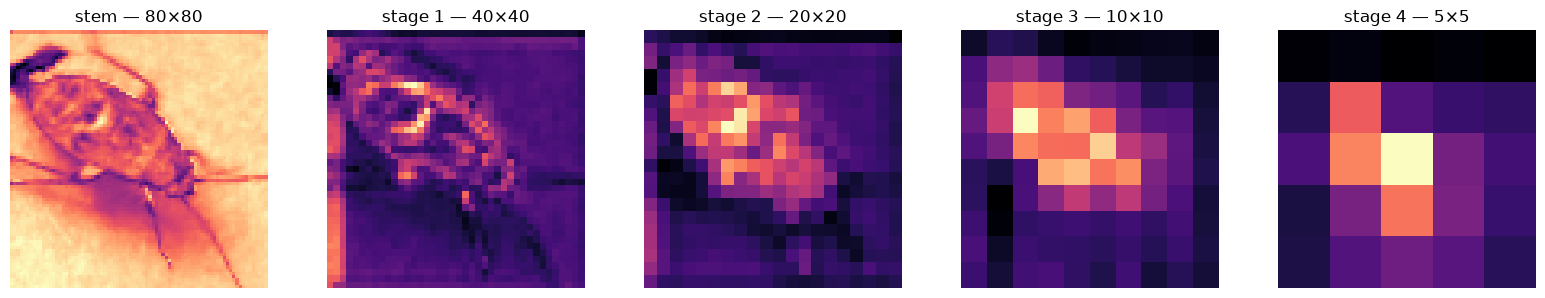

In [14]:
%matplotlib inline

import matplotlib.pyplot as plt

# Separate model so we do not alter the model/result used later by save_run.
viz_model = CustomCNN(num_classes=protocol.num_classes)
viz_model.load_state_dict(result.best_state_dict, strict=True)
viz_model = viz_model.to(device).eval()

activations = {}

def capture(name):
    def hook(module, inputs, output):
        activations[name] = output.detach().cpu()
    return hook

observed_layers = {
    "stem — 80×80": viz_model.stem,
    "stage 1 — 40×40": viz_model.stages[0],
    "stage 2 — 20×20": viz_model.stages[1],
    "stage 3 — 10×10": viz_model.stages[2],
    "stage 4 — 5×5": viz_model.stages[3],
}

handles = [
    layer.register_forward_hook(capture(name))
    for name, layer in observed_layers.items()
]

# Use validation, never test, for exploratory visualisation.
batch = next(iter(loaders["validation"]))
images, targets = batch[0], batch[1]

with torch.no_grad():
    logits = viz_model(images[:1].to(device))

for handle in handles:
    handle.remove()

prediction = logits.argmax(dim=1).item()
print("True class:", protocol.class_names[targets[0].item()])
print("Predicted :", protocol.class_names[prediction])

fig, axes = plt.subplots(1, len(activations), figsize=(16, 3))

for ax, (name, tensor) in zip(axes, activations.items()):
    # Average absolute activation across channels to produce one spatial map.
    heatmap = tensor[0].abs().mean(dim=0)
    ax.imshow(heatmap, cmap="magma")
    ax.set_title(name)
    ax.axis("off")

plt.tight_layout()
plt.show()

## 5. Error analysis

The report needs at least ten inspected failures. `predictions.csv` has every
test image with its prediction and confidence, so start with the confident
mistakes — those are where the model has learned something wrong, as opposed to
merely being unsure.

In [15]:
import pandas as pd

preds  = pd.read_csv(run_dir / 'predictions.csv')
wrong  = preds[preds.correct == 0].sort_values('confidence', ascending=False)

print(f'{len(wrong)} errors out of {len(preds)} test images\n')
print('most confident mistakes:')
display(wrong.head(10)[['image_path', 'true_class', 'predicted_class', 'confidence']])

print('\nmost frequent confusions:')
display(wrong.groupby(['true_class', 'predicted_class']).size()
             .sort_values(ascending=False).head(10).rename('count').reset_index())

438 errors out of 1447 test images

most confident mistakes:


,image_path,true_class,predicted_class,confidence
1170,IP015000527.jpg,grub,flax_budworm,1.0000
21,IP052000504.jpg,blister_beetle,aphids,1.0000
1227,IP102000020.jpg,cicadellidae,cicadella_viridis,0.9999
616,IP102004444.jpg,cicadellidae,army_worm,0.9998
750,IP102000586.jpg,cicadellidae,cicadella_viridis,0.9998
477,IP046000900.jpg,flax_budworm,corn_borer,0.9995
1145,IP023000567.jpg,corn_borer,prodenia_litura,0.9995
139,IP102000490.jpg,cicadellidae,cicadella_viridis,0.9994
772,IP024001151.jpg,army_worm,cicadellidae,0.9994
508,IP102002842.jpg,cicadellidae,army_worm,0.9989



most frequent confusions:


,true_class,predicted_class,count
0,cicadellidae,cicadella_viridis,25
1,miridae,cicadellidae,20
2,miridae,blister_beetle,17
3,cicadellidae,prodenia_litura,16
4,cicadellidae,miridae,15
5,miridae,tarnished_plant_bug,15
6,prodenia_litura,flax_budworm,12
7,cicadellidae,army_worm,12
8,army_worm,miridae,12
9,army_worm,cicadellidae,12


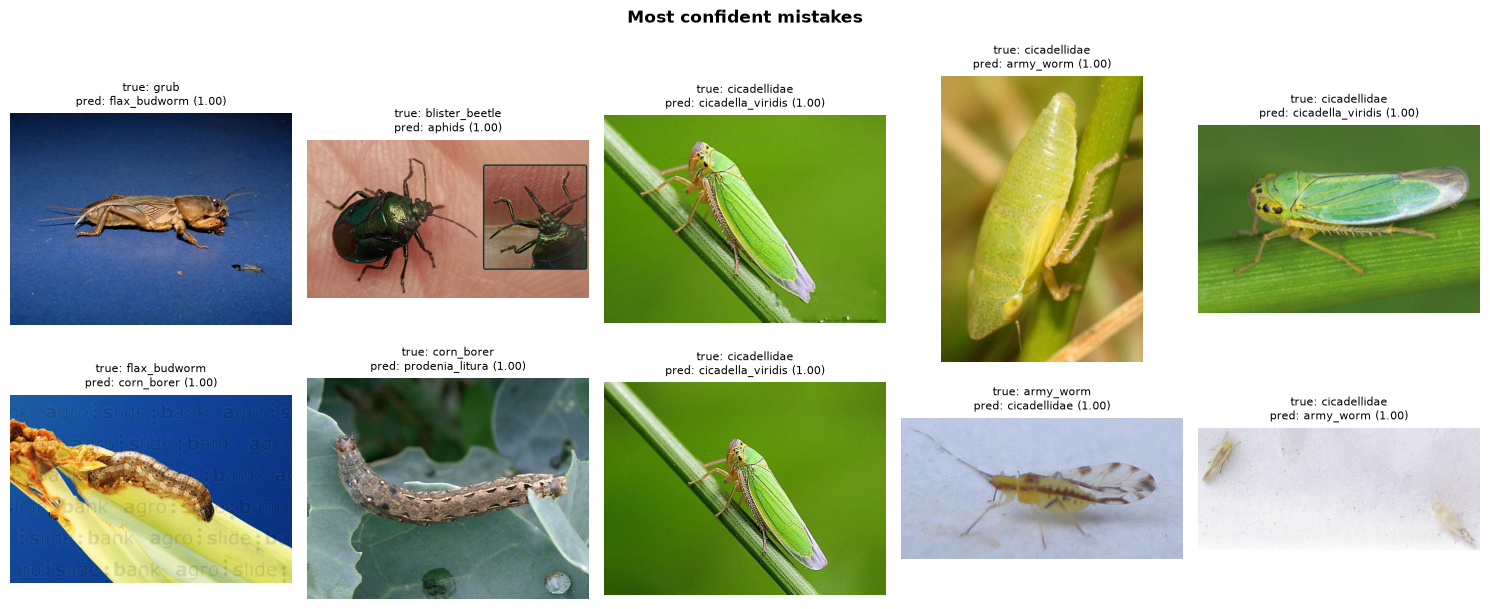

In [16]:
from PIL import Image
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 5, figsize=(15, 6.5))
for ax, (_, row) in zip(axes.ravel(), wrong.head(10).iterrows()):
    ax.imshow(Image.open(protocol.image_root / row.image_path).convert('RGB'))
    ax.set_title(f"true: {row.true_class}\npred: {row.predicted_class} ({row.confidence:.2f})",
                 fontsize=8)
    ax.axis('off')
fig.suptitle('Most confident mistakes', fontweight='bold')
fig.tight_layout(); plt.show()

## 6. Where you stand

Compares your run against everyone else's. Run it again after your teammates push.

In [17]:
!cd .. && python -m ip102_bench.compare


Protocol v1, subset 'detection_top15' -- primary metric: macro F1

       model_name  author  pretrained  macro_f1  test_accuracy  best_val_macro_f1  parameters  model_size_mb  cpu_inference_ms  best_epoch  epochs_trained  training_seconds          run_id
custom_cnn_ziyang Zi Yang       False   0.60734       0.697305           0.608469     1437167         5.6311            7.9194          51            60.0           3268.52 20260804-224054

1 run(s) excluded -- recorded under a different protocol version or subset:
  custom_cnn_ziyang        vlegacy-det_top15-external subset=detection_top15  D:\SiT Stuffff\Year 2\OIP Vietnam\Project\New folder_3\FarmPestManagementAI-integration\runs\custom_cnn_ziyang\20260804_legacy_epoch48
Re-run these before quoting them alongside the table above.
